In [33]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from adjustText import adjust_text

    

sns.set_theme(style="whitegrid")    

plt.rcParams.update({
    "axes.titleweight": "bold",
    "font.size": 11,
    "axes.labelweight": "bold",
    "figure.dpi": 120,})

In [34]:
def load_summary(path="evaluation_summary.json"):
    with open(path, "r") as f:
        return json.load(f)


def build_palette(data):
    model_names = sorted({d["model"] for d in data})
    palette = sns.color_palette("tab10", n_colors=len(model_names))
    return dict(zip(model_names, palette))


def extract_overall(summary):
    data = []

    for model_name, model_data in summary.items():
        overall = model_data.get("overall", {})

        data.append({
            "model": model_name,
            "win_rate": overall.get("win_rate", 0),
            "avg_turn": overall.get("avg_found_solution_turn", np.nan),
            "info_gain": overall.get("avg_info_gain_per_suggestion", 0),
            "memory": overall.get("memory_score", 0),
            "repeated": overall.get("avg_repeated_suggestions", 0),
            "wrong_acc": overall.get("wrong_accusations", 0),
        })
    return data
summary = load_summary()

data = extract_overall(summary)
palette = build_palette(data)




In [35]:
def plot_win_rate(data, palette):
    data_sorted = sorted(data, key=lambda x: x["win_rate"])
    models = [d["model"] for d in data_sorted]
    values = [d["win_rate"] for d in data_sorted]
    colors = [palette[m] for m in models]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=values, y=models, palette=colors, ax=ax, edgecolor="black", linewidth=0.8)

    for i, v in enumerate(values):
        ax.text(v + 0.01, i, f"{v:.0%}", va="center", ha="left", fontsize=10)

    ax.set_xlim(0, 1)
    ax.set_xlabel("Win rate")
    ax.set_ylabel("")
    ax.set_title("Model Performance: Win Rate")
    sns.despine(ax=ax, left=True, bottom=False)

    fig.tight_layout()
    fig.savefig("figures/win_rate.png", dpi=300)
    plt.show()

In [36]:
def plot_efficiency(data, palette):
    x = [d["avg_turn"] for d in data]
    y = [d["info_gain"] for d in data]
    labels = [d["model"] for d in data]
    colors = [palette[m] for m in labels]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, s=200, c=colors, edgecolors="black", linewidth=0.8)

    for xi, yi, label in zip(x, y, labels):
        ax.text(xi + 0.12, yi + 0.02, label, fontsize=10, weight="bold")

    ax.set_xlabel("Avg solution turn (lower is better)")
    ax.set_ylabel("Info gain per suggestion")
    ax.set_title("Reasoning Efficiency Frontier")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig("figures/efficiency.png", dpi=300)
    plt.show()

In [37]:
def plot_memory(data, palette):
    x = [d["memory"] for d in data]
    y = [d["repeated"] for d in data]
    labels = [d["model"] for d in data]
    colors = [palette[m] for m in labels]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, s=200, c=colors, edgecolors="black", linewidth=0.8)

    for xi, yi, label in zip(x, y, labels):
        ax.text(xi + 0.02, yi + 0.08, label, fontsize=10, weight="bold")

    ax.set_xlabel("Memory score (higher better)")
    ax.set_ylabel("Repeated suggestions (lower better)")
    ax.set_title("Memory vs Repetition")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig("figures/memory.png", dpi=300)
    plt.show()

In [38]:
def plot_failures(data, palette):
    models = [d["model"] for d in data]
    failures = [d["wrong_acc"] for d in data]

    order = np.argsort(failures)
    models = [models[i] for i in order]
    failures = [failures[i] for i in order]
    colors = [palette[m] for m in models]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=failures, y=models, palette=colors, ax=ax, edgecolor="black", linewidth=0.8)

    offset = max(0.3, max(failures) * 0.02) if failures else 0.3
    for i, v in enumerate(failures):
        ax.text(v + offset, i, str(v), va="center", ha="left", fontsize=10)

    ax.set_xlabel("Wrong accusations")
    ax.set_ylabel("")
    ax.set_title("Safety / Reliability: Failure Rate")

    sns.despine(ax=ax, left=True, bottom=False)    
    plt.show()

    fig.savefig("figures/failures.png", dpi=300)
    fig.tight_layout()

/tmp/ipykernel_11438/451432443.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=models, palette=colors, ax=ax, edgecolor="black", linewidth=0.8)


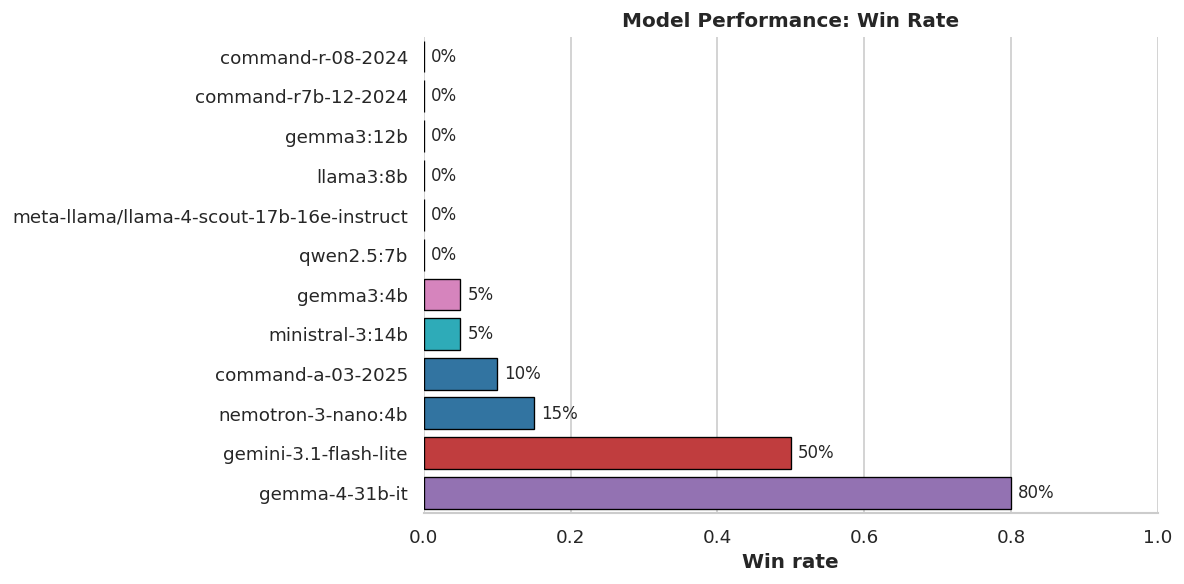

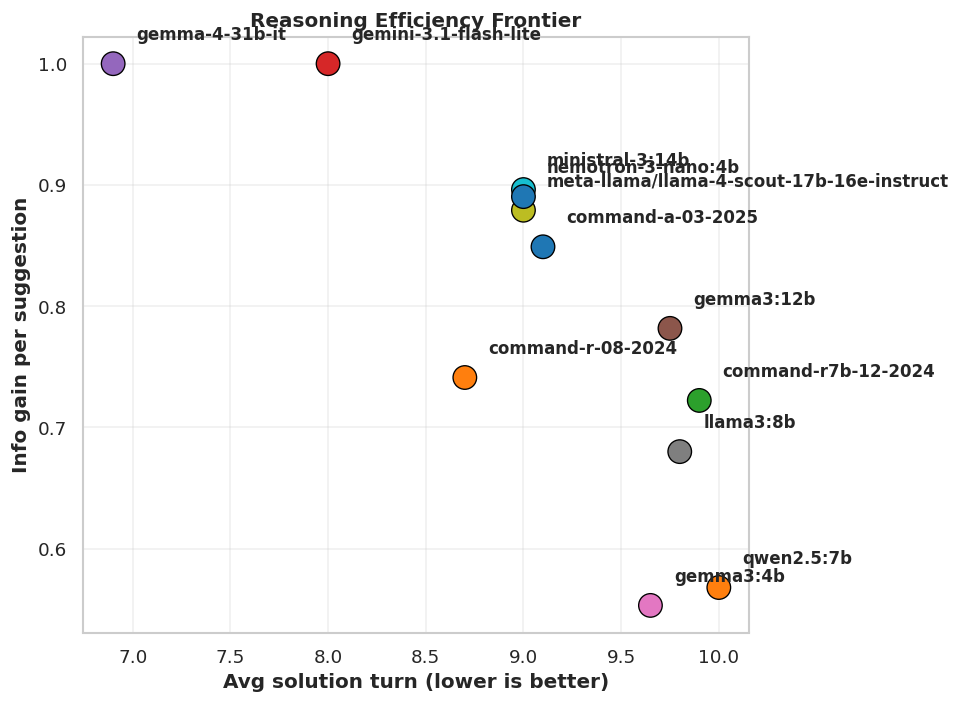

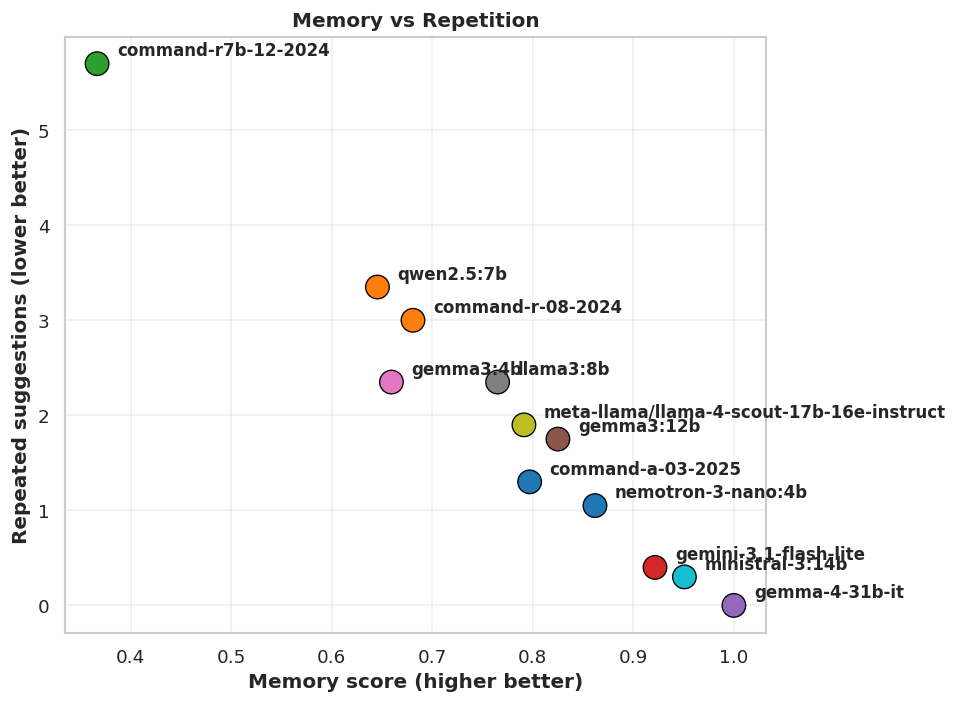

/tmp/ipykernel_11438/880504893.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failures, y=models, palette=colors, ax=ax, edgecolor="black", linewidth=0.8)


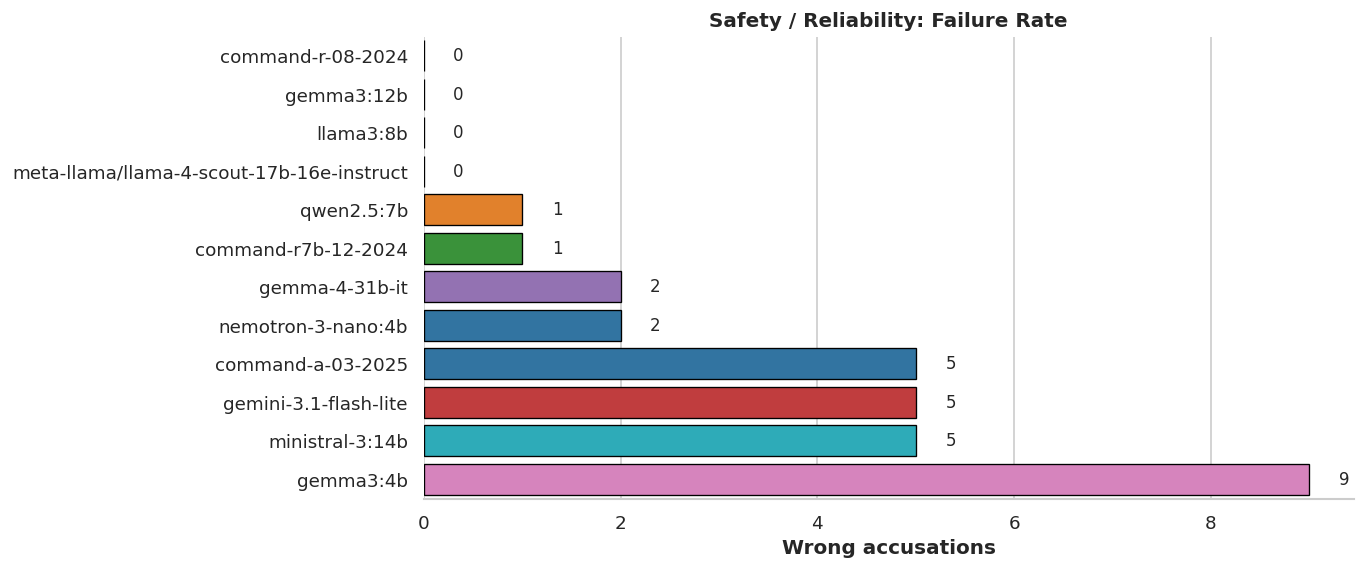

In [39]:
def run_all():
    plot_win_rate(data, palette)
    plot_efficiency(data, palette)
    plot_memory(data, palette)
    plot_failures(data, palette)

run_all()

In [40]:
def load_data(path="evaluation_summary.json"):
    with open(path, "r") as f:
        return json.load(f)

data = load_data()

In [41]:
import re
import pandas as pd

def clean_model_name(model):
    # Remove directory prefix (e.g. meta-llama/model_name)
    model = model.split("/")[-1]

    # Remove trailing date suffixes like -04-2025
    model = re.sub(r"-\d{2}-\d{4}$", "", model)

    return model


def to_rows(summary):
    rows = []

    for model, content in summary.items():

        model_name = clean_model_name(model)

        # overall
        overall = content.get("overall", {})
        rows.append({
            "model": model_name,
            "position": "overall",
            **overall
        })

        # positions
        for k, v in content.items():
            if k.startswith("position_"):
                rows.append({
                    "model": model_name,
                    "position": k,
                    **v
                })

    return pd.DataFrame(rows)

df = to_rows(data)

In [42]:
def plot_pareto(df):

    d = df[df["position"] == "overall"].copy()

    # -------------------------
    # Model families
    # -------------------------
    def family(model):
        if model.startswith("command"):
            return "Cohere"
        elif model.startswith("gem"):
            return "Google"
        else:
            return "Other"

    d["Family"] = d["model"].apply(family)

    plt.figure(figsize=(10, 7))

    ax = sns.scatterplot(
        data=d,
        x="avg_info_gain_per_suggestion",
        y="win_rate",
        size="memory_score",
        sizes=(100, 1200),
        hue="Family",
        alpha=0.8,
        legend="brief"
    )

    # -------------------------
    # FIX LEGEND PROPERLY
    # -------------------------
    handles, labels = ax.get_legend_handles_labels()

    new_labels = []
    for lab in labels:
        if lab == "memory_score":
            new_labels.append("Memory Score")
        else:
            new_labels.append(lab)

    ax.legend(handles, new_labels, title="Family + Size", loc="best")

    # -------------------------
    # Add model labels (no overlap)
    # -------------------------
    texts = []
    for _, row in d.iterrows():
        texts.append(
            ax.text(
                row["avg_info_gain_per_suggestion"],
                row["win_rate"],
                row["model"],
                fontsize=8
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )

    # Ideal corner
    plt.axvline(
        d["avg_info_gain_per_suggestion"].median(),
        ls="--",
        alpha=0.3
    )

    plt.axhline(
        d["win_rate"].median(),
        ls="--",
        alpha=0.3
    )

    # -------------------------
    # Titles and labels
    # -------------------------
    plt.title(
        "Reasoning Efficiency vs Win Rate",
        fontsize=16,
        weight="bold"
    )

    plt.xlabel(
        "Average Information Gain per Suggestion",
        fontsize=12
    )

    plt.ylabel(
        "Win Rate",
        fontsize=12
    )

    plt.tight_layout()

    plt.savefig(
        "figures/pareto_frontier.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [43]:
def plot_position_bias(df):
    pos = df[df["position"] != "overall"].copy()

    # keep only models that have at least one win
    winning_models = (
        df.groupby("model")["win_rate"]
        .sum()
        .loc[lambda x: x > 0]
        .index
    )

    pos = pos[pos["model"].isin(winning_models)]

    agg = pos.groupby(["model", "position"])[
        ["win_rate", "avg_info_gain_per_suggestion", "avg_suggestions"]
    ].mean().reset_index()

    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=agg,
        x="position",
        y="win_rate",
        hue="model",
        marker="o"
    )

    plt.title("Position Bias: Win Rate vs Player Order")
    plt.xlabel("Player Position")
    plt.ylabel("Win Rate")

    plt.tight_layout()
    plt.savefig("figures/position_bias.png")
    plt.show()

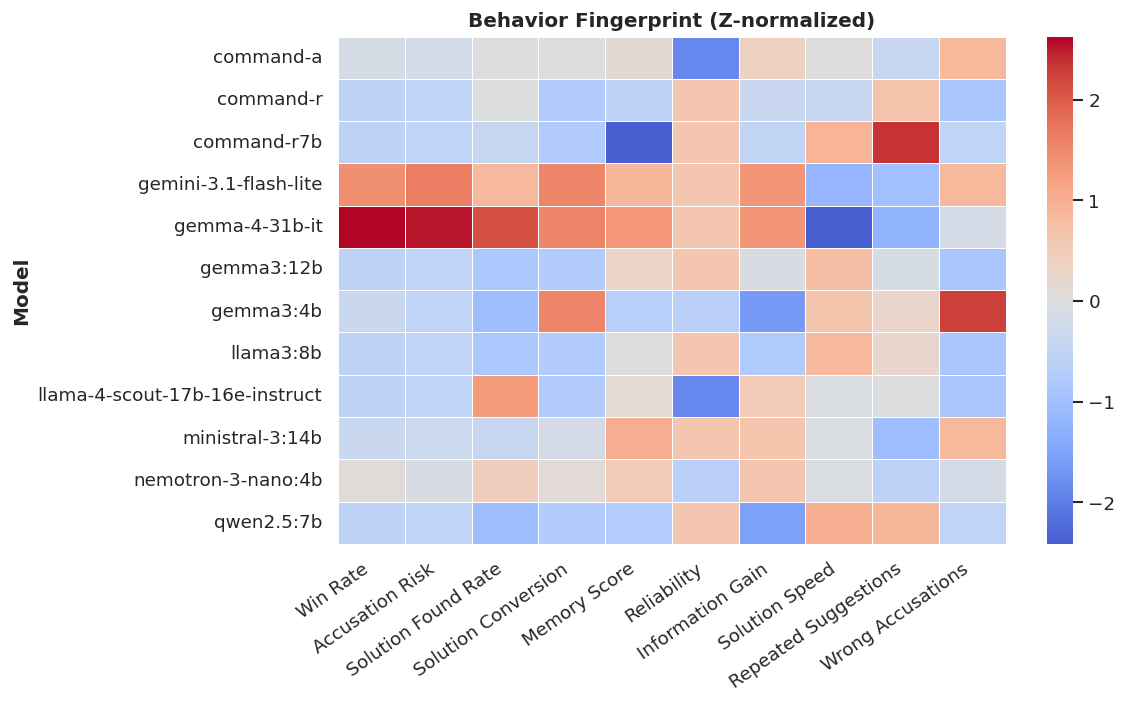

In [44]:
def plot_fingerprint(df):
    d = df[df["position"] == "overall"].copy()

    features = [
        "win_rate",
        "avg_risk",
        "found_solution_rate",
        "solution_conversion_rate",
        "memory_score",
        "reliability_score",
        "avg_info_gain_per_suggestion",
        "avg_found_solution_turn",
        "avg_repeated_suggestions",
        "wrong_accusations",
    ]

    feature_names = {
        "win_rate": "Win Rate",
        "avg_risk": "Accusation Risk",
        "found_solution_rate": "Solution Found Rate",
        "solution_conversion_rate": "Solution Conversion",
        "memory_score": "Memory Score",
        "reliability_score": "Reliability",
        "avg_info_gain_per_suggestion": "Information Gain",
        "avg_found_solution_turn": "Solution Speed",
        "avg_repeated_suggestions": "Repeated Suggestions",
        "wrong_accusations": "Wrong Accusations",
    }

    mat = d.set_index("model")[features]

    # normalize for comparability
    mat = (mat - mat.mean()) / (mat.std())

    # rename columns for display
    mat = mat.rename(columns=feature_names)

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        mat,
        annot=False,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
    )

    plt.xticks(rotation=35, ha="right")

    plt.title("Behavior Fingerprint (Z-normalized)")
    plt.xlabel("")
    plt.ylabel("Model")

    plt.tight_layout()
    plt.savefig("figures/behavior_fingerprint.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_fingerprint(df)

In [45]:
def plot_radar(df):

    d = df[df["position"] == "overall"].copy()

    categories = [
        "memory_score",
        "avg_info_gain_per_suggestion",
        "reliability_score",
        "win_rate"
    ]



    # ----------------------------------
    # Split into model families
    # ----------------------------------
    families = {
        "Cohere Models":
            d[d["model"].str.startswith("command")],

        "Google Models":
            d[d["model"].str.startswith("gem")],

        "Other Models":
            d[
                ~d["model"].str.startswith("command")
                &
                ~d["model"].str.startswith("gem")
            ]
    }

    angles = np.linspace(
        0,
        2 * np.pi,
        len(categories),
        endpoint=False
    ).tolist()

    angles += angles[:1]

    # ----------------------------------
    # Create subplots
    # ----------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6),
        subplot_kw=dict(polar=True)
    )

    for ax, (family_name, family_df) in zip(
        axes,
        families.items()
    ):

        if family_df.empty:
            ax.set_visible(False)
            continue

        for _, row in family_df.iterrows():

            values = [row[c] for c in categories]
            values += values[:1]

            ax.plot(
                angles,
                values,
                linewidth=2,
                label=row["model"]
            )

            ax.fill(
                angles,
                values,
                alpha=0.05
            )

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(
            [
                "Memory",
                "Info Gain",
                "Reliability",
                "Win Rate"
            ]
        )

        ax.set_ylim(0, 1)

        ax.set_title(
            family_name,
            pad=20,
            fontsize=14,
            fontweight="bold"
        )

        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.15),
            fontsize=8,
            frameon=False
        )

    plt.suptitle(
        "Model Behavior Profiles (Normalized)",
        fontsize=18,
        y=1.05
    )

    plt.tight_layout()

    plt.savefig(
        "figures/behavior_radar_families.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [46]:
def plot_solution_speed_vs_info_gain(df):

    d = df[df["position"] == "overall"].copy()

    def family(model):
        if model.startswith("command"):
            return "Cohere"
        elif model.startswith("gem"):
            return "Google"
        else:
            return "Other"

    d["Family"] = d["model"].apply(family)

    plt.figure(figsize=(10, 7))

    ax = sns.scatterplot(
        data=d,
        x="avg_found_solution_turn",
        y="avg_info_gain_per_suggestion",
        size="solution_conversion_rate",
        sizes=(100, 1500),
        hue="Family",
        alpha=0.8,
        legend="brief"
    )
    # -------------------------
    # FIX LEGEND PROPERLY
    # -------------------------
    handles, labels = ax.get_legend_handles_labels()

    new_labels = []
    for lab in labels:
        if lab == "solution_conversion_rate":
            new_labels.append("Solution Conversion Rate")
        else:
            new_labels.append(lab)

    ax.legend(handles, new_labels, title="Family + Size", loc="best")


    # -------------------------
    # FIX OVERLAPPING LABELS
    # -------------------------
    texts = []
    for _, row in d.iterrows():
        texts.append(
            ax.text(
                row["avg_found_solution_turn"],
                row["avg_info_gain_per_suggestion"],
                row["model"],
                fontsize=8
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )

    # Ideal corner
    plt.axvline(
        d["avg_found_solution_turn"].median(),
        ls="--",
        alpha=0.3
    )

    plt.axhline(
        d["avg_info_gain_per_suggestion"].median(),
        ls="--",
        alpha=0.3
    )

    plt.gca().invert_xaxis()

    plt.title(
        "Solution Discovery Speed vs Information Gain",
        fontsize=16,
        weight="bold"
    )

    plt.xlabel(
        "Average Turn Solution Found (lower is better)",
        fontsize=12
    )

    plt.ylabel(
        "Information Gain per Suggestion",
        fontsize=12
    )

    plt.tight_layout()

    plt.savefig(
        "figures/solution_speed_vs_info_gain.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [47]:


def plot_risk_vs_winrate(df):

    # -------------------------
    # keep only overall stats
    # -------------------------
    d = df[df["position"] == "overall"].copy()

    # -------------------------
    # filter: models that have at least one win
    # -------------------------
    d = d[d["win_rate"] > 0]

    # -------------------------
    # model family
    # -------------------------
    def family(model):
        if model.startswith("command"):
            return "Cohere"
        elif model.startswith("gem"):
            return "Google"
        else:
            return "Other"

    d["Family"] = d["model"].apply(family)

    # -------------------------
    # plot
    # -------------------------
    plt.figure(figsize=(10, 7))

    ax = sns.scatterplot(
        data=d,
        x="avg_risk",
        y="win_rate",
        hue="Family",
        size="wrong_accusations",
        sizes=(100, 1200),
        alpha=0.8
    )

    # -------------------------
    # clean labels (no overlap)
    # -------------------------
    texts = []
    for _, row in d.iterrows():
        texts.append(
            ax.text(
                row["avg_risk"],
                row["win_rate"],
                row["model"],
                fontsize=8
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )

    # -------------------------
    # styling
    # -------------------------
    plt.title("Risk vs Win Rate", fontsize=16, weight="bold")
    plt.xlabel("Average Risk", fontsize=12)
    plt.ylabel("Win Rate", fontsize=12)

    plt.tight_layout()

    plt.savefig(
        "figures/risk_vs_winrate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

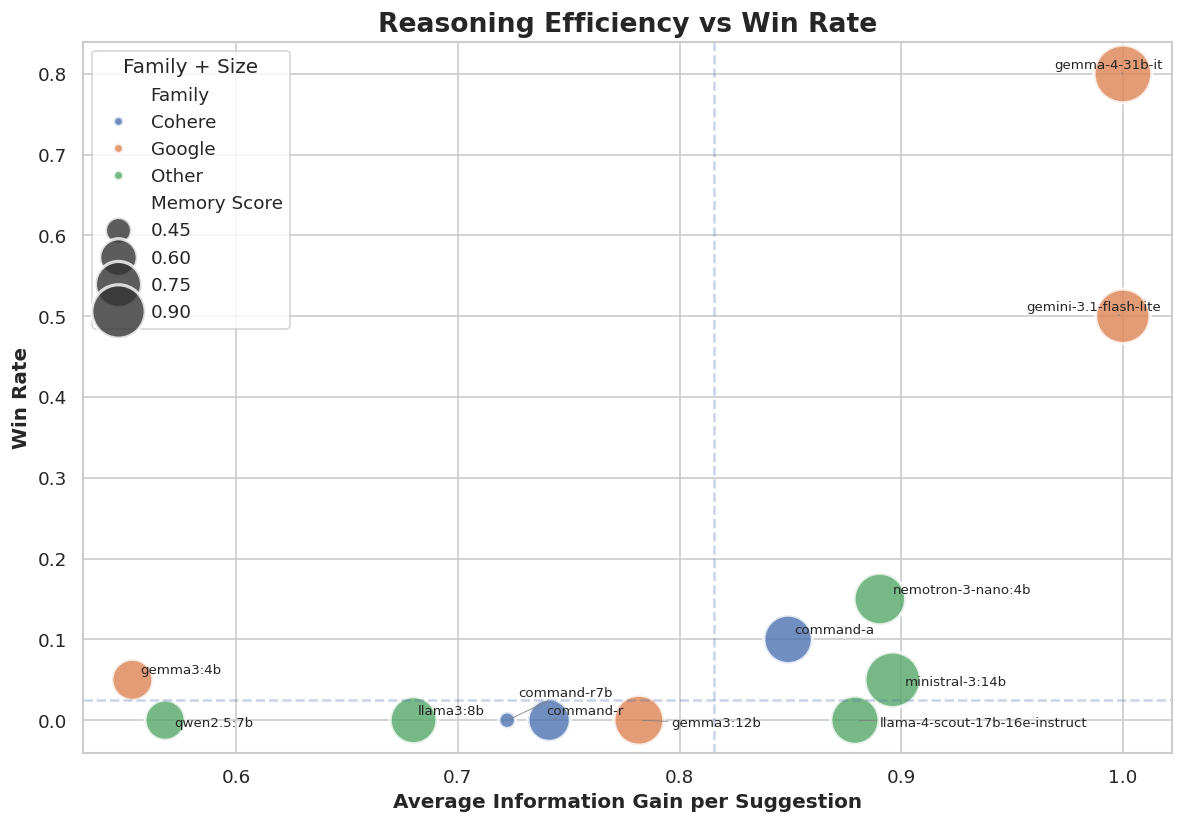

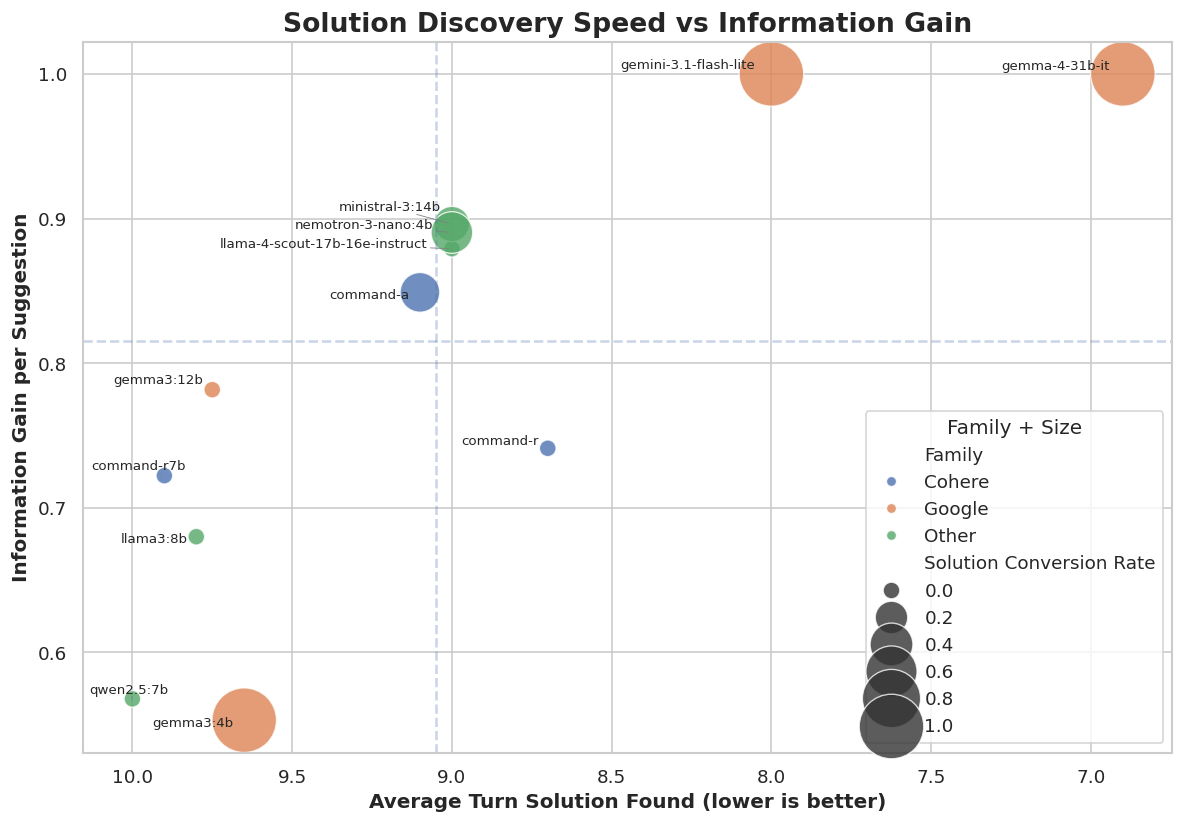

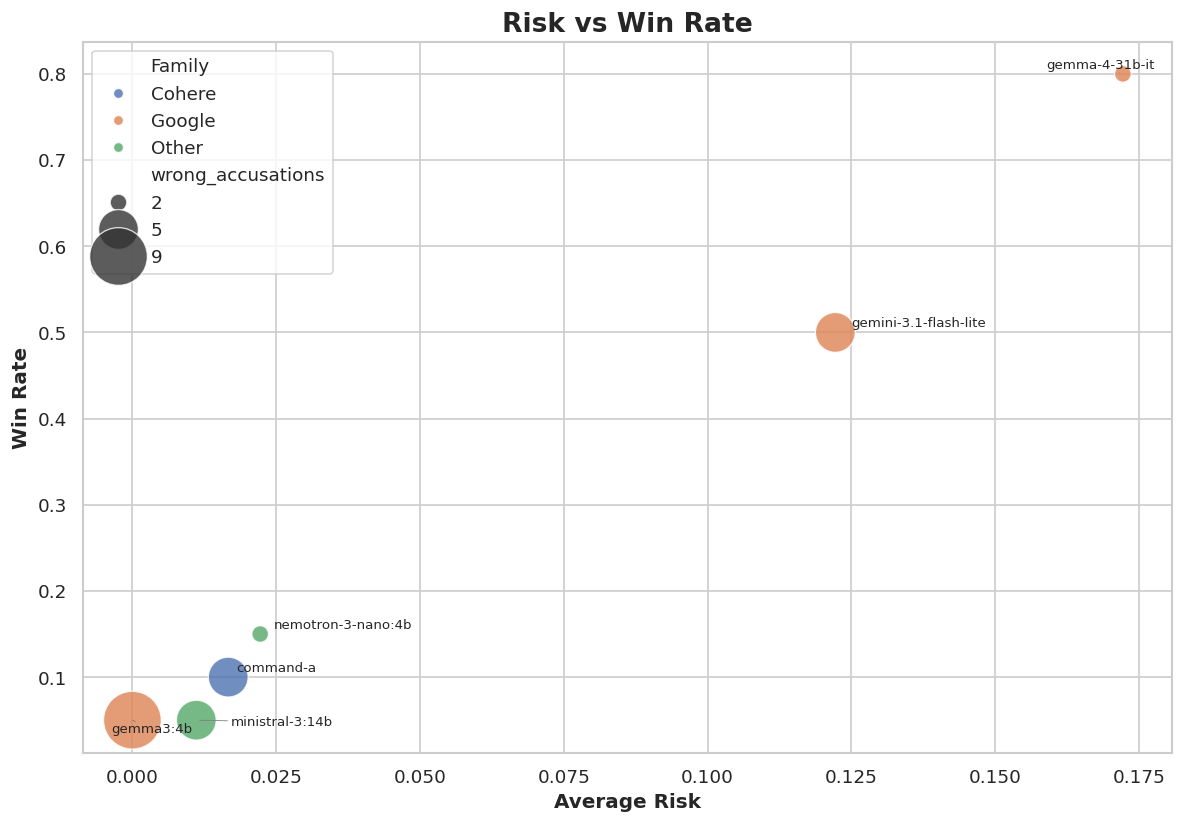

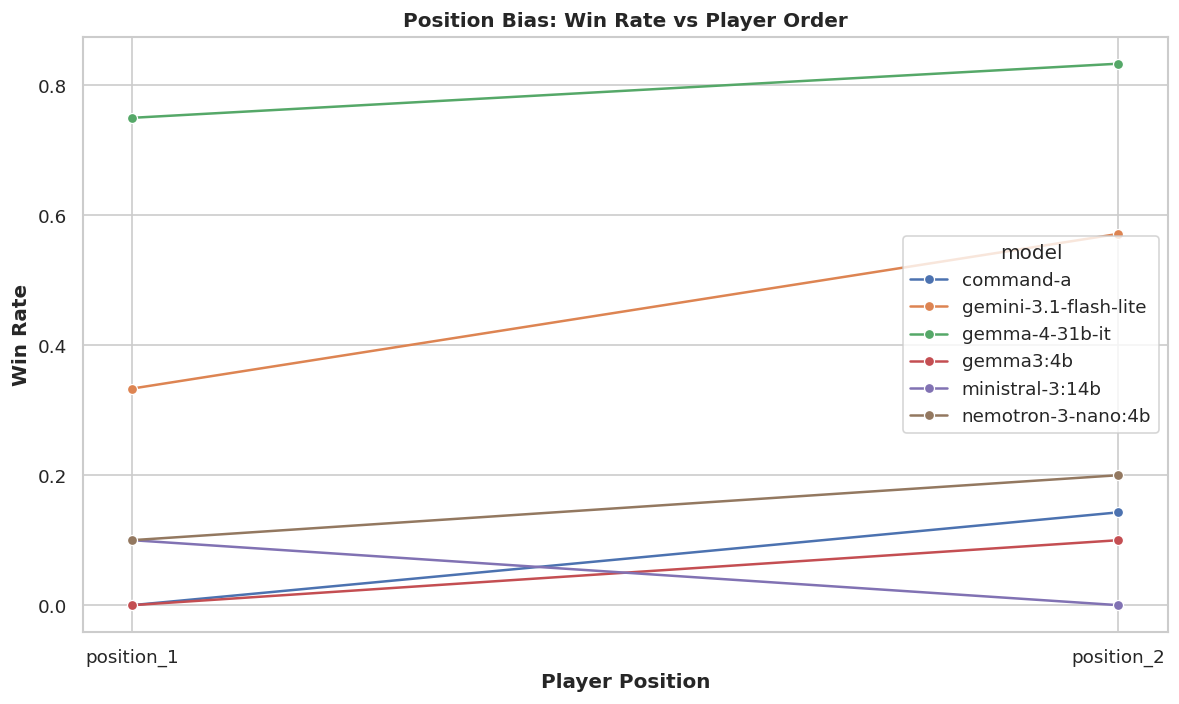

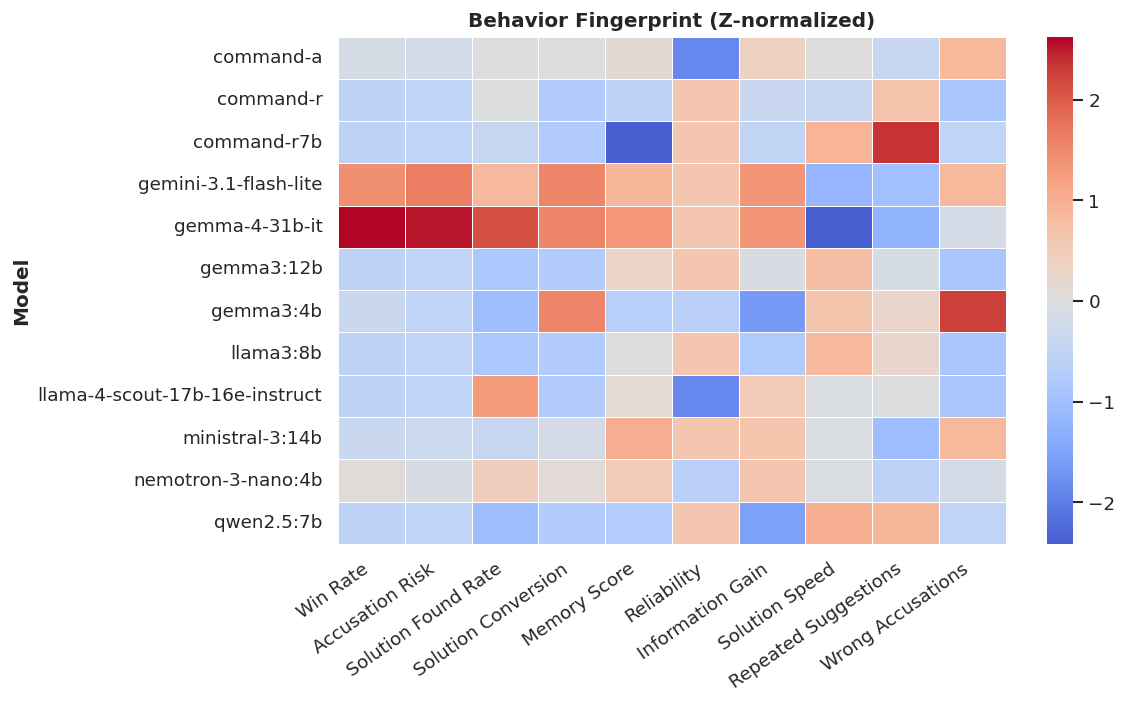

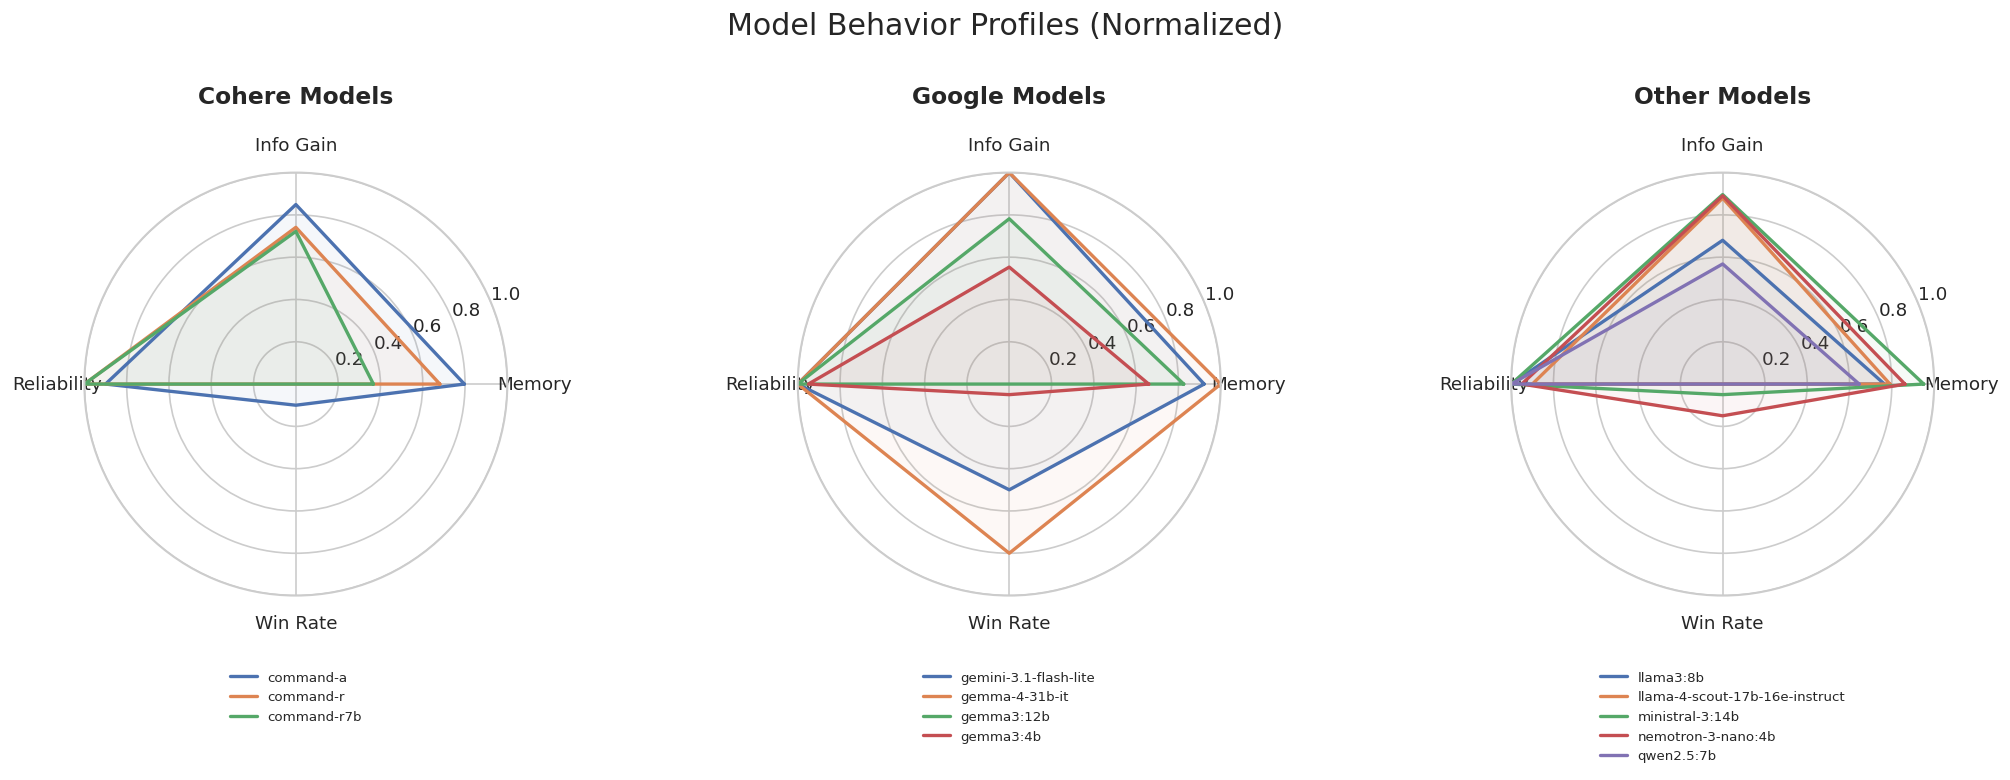

In [48]:
plot_pareto(df)
plot_solution_speed_vs_info_gain(df)
plot_risk_vs_winrate(df)
plot_position_bias(df)
plot_fingerprint(df)
plot_radar(df)